## Imports and helper functions

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

FIG_DIR = "assign7_figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_figure(name):
    plt.tight_layout()
    png_path = os.path.join(FIG_DIR, f"{name}.png")
    eps_path = os.path.join(FIG_DIR, f"{name}.eps")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(eps_path, format="eps", dpi=600, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {eps_path}")

def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    results = {
        "Model": model_name,
        "Accuracy (%)": round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4),
        "AUC": round(roc_auc_score(y_test, y_score), 4)
    }
    return y_pred, y_score, results

def plot_confusion(model_name, y_true, y_pred, file_label):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    save_figure(file_label)
    plt.show()

def plot_roc(model_name, y_true, y_score, file_label):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_value = roc_auc_score(y_true, y_score)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend()
    save_figure(file_label)
    plt.show()

## Load the dataset

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = pd.Series(data.target, name="target")   # 0 = malignant, 1 = benign in sklearn

# Convert target to: 1 = malignant, 0 = benign
y = y.map({0: 1, 1: 0})

print("Dataset shape:", X.shape)
print("Target distribution:")
print(y.value_counts().rename(index={1: "Malignant", 0: "Benign"}))

display(X.head())

Dataset shape: (569, 30)
Target distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Exploratory Data Analysis (EDA)

Saved: assign7_figures\fig01_class_distribution.png
Saved: assign7_figures\fig01_class_distribution.eps


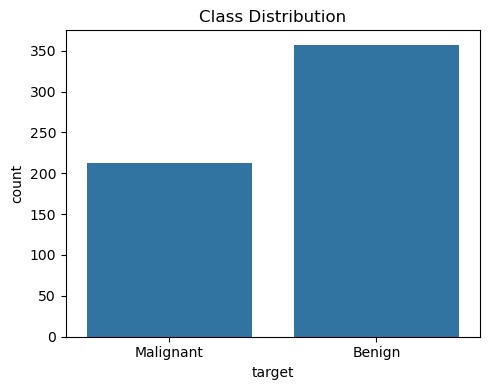

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


In [3]:
eda_df = X.copy()
eda_df["target"] = y.map({1: "Malignant", 0: "Benign"})

plt.figure(figsize=(5, 4))
sns.countplot(x="target", data=eda_df)
plt.title("Class Distribution")
save_figure("fig01_class_distribution")
plt.show()

summary_table = X.describe().T
display(summary_table.head(10))

Top 10 features most correlated with target:
['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter', 'worst area', 'mean radius', 'mean area', 'mean concavity', 'worst concavity']
Saved: assign7_figures\fig02_top10_correlation_heatmap.png
Saved: assign7_figures\fig02_top10_correlation_heatmap.eps


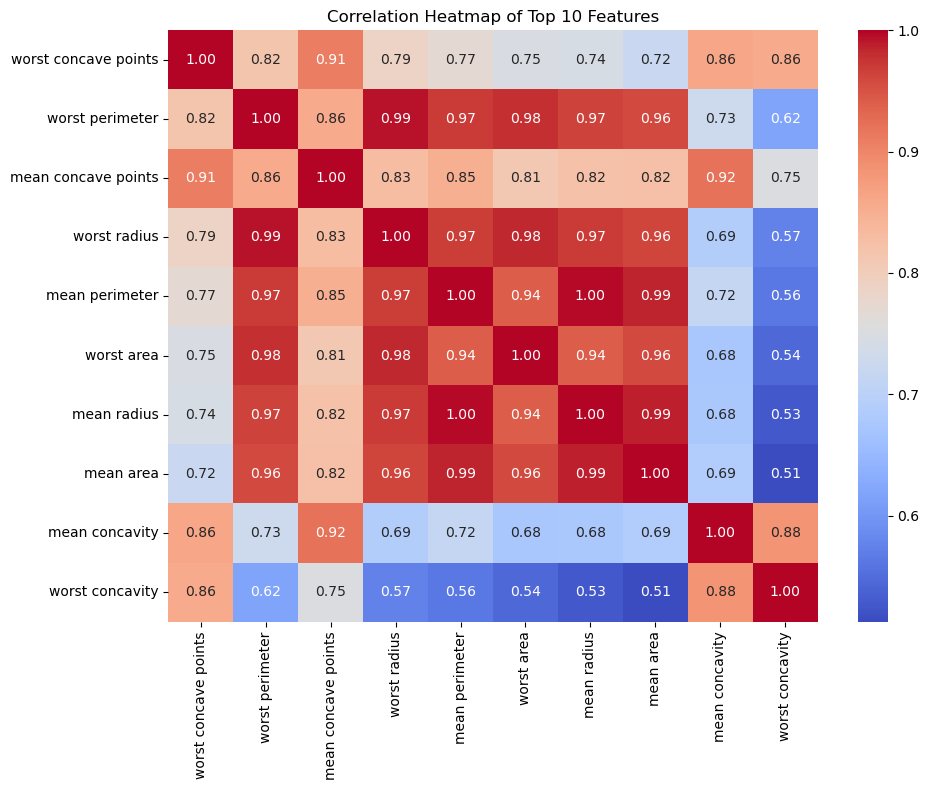

In [4]:
top_features = X.corrwith(y).abs().sort_values(ascending=False).head(10).index.tolist()
print("Top 10 features most correlated with target:")
print(top_features)

plt.figure(figsize=(10, 8))
sns.heatmap(X[top_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Top 10 Features")
save_figure("fig02_top10_correlation_heatmap")
plt.show()

Saved: assign7_figures\fig03_selected_feature_histograms.png
Saved: assign7_figures\fig03_selected_feature_histograms.eps


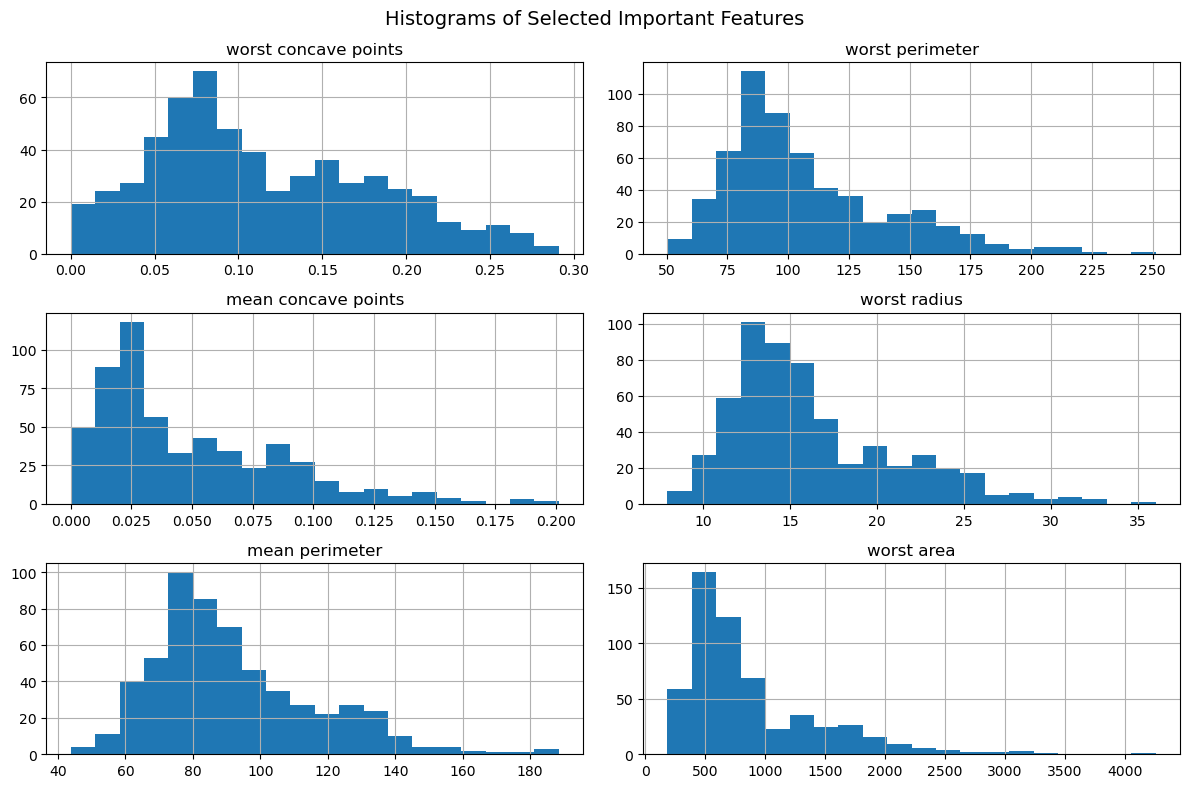

In [5]:
X[top_features[:6]].hist(figsize=(12, 8), bins=20)
plt.suptitle("Histograms of Selected Important Features", fontsize=14)
save_figure("fig03_selected_feature_histograms")
plt.show()

## Train-test split (80:20)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print("y_test distribution:")
print(y_test.value_counts(normalize=True))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_train: (455, 30)
X_test : (114, 30)
y_train distribution:
target
0    0.626374
1    0.373626
Name: proportion, dtype: float64
y_test distribution:
target
0    0.631579
1    0.368421
Name: proportion, dtype: float64


## Bagging model and hyperparameter search

In [7]:
bagging_param_grid = {
    "n_estimators": [10, 50],
    "max_samples": [0.7, 1.0],
    "max_features": [0.7, 1.0]
}

bagging_base = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

bagging_grid = GridSearchCV(
    estimator=bagging_base,
    param_grid=bagging_param_grid,
    scoring={"accuracy": "accuracy", "f1": "f1"},
    refit="accuracy",
    cv=cv,
    n_jobs=-1
)

bagging_grid.fit(X_train, y_train)

bagging_cv_results = pd.DataFrame({
    "n_estimators": bagging_grid.cv_results_["param_n_estimators"].astype(int),
    "max_samples": bagging_grid.cv_results_["param_max_samples"].astype(float),
    "max_features": bagging_grid.cv_results_["param_max_features"].astype(float),
    "Avg CV Accuracy (%)": np.round(bagging_grid.cv_results_["mean_test_accuracy"] * 100, 2),
    "Avg CV F1 Score": np.round(bagging_grid.cv_results_["mean_test_f1"], 4)
}).sort_values(by="Avg CV Accuracy (%)", ascending=False)

print("Best Bagging Parameters:", bagging_grid.best_params_)
display(bagging_cv_results)

Best Bagging Parameters: {'max_features': 1.0, 'max_samples': 0.7, 'n_estimators': 50}


,n_estimators,max_samples,max_features,Avg CV Accuracy (%),Avg CV F1 Score
5,50,0.7,1.0,96.48,0.9515
0,10,0.7,0.7,96.04,0.9469
3,50,1.0,0.7,96.04,0.9463
6,10,1.0,1.0,96.04,0.9459
7,50,1.0,1.0,96.04,0.9467
1,50,0.7,0.7,95.60,0.9400
4,10,0.7,1.0,94.73,0.9261
2,10,1.0,0.7,94.07,0.9171


## Boosting models and hyperparameter search

In [8]:
adaboost_param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.5, 1.0]
}

adaboost_base = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    random_state=42
)

adaboost_grid = GridSearchCV(
    estimator=adaboost_base,
    param_grid=adaboost_param_grid,
    scoring={"accuracy": "accuracy", "f1": "f1"},
    refit="accuracy",
    cv=cv,
    n_jobs=-1
)

adaboost_grid.fit(X_train, y_train)

adaboost_cv_results = pd.DataFrame({
    "Algorithm": "AdaBoost",
    "n_estimators": adaboost_grid.cv_results_["param_n_estimators"].astype(int),
    "learning_rate": adaboost_grid.cv_results_["param_learning_rate"].astype(float),
    "max_depth": 1,
    "Avg CV Accuracy (%)": np.round(adaboost_grid.cv_results_["mean_test_accuracy"] * 100, 2),
    "Avg CV F1 Score": np.round(adaboost_grid.cv_results_["mean_test_f1"], 4)
}).sort_values(by="Avg CV Accuracy (%)", ascending=False)

print("Best AdaBoost Parameters:", adaboost_grid.best_params_)
display(adaboost_cv_results)

Best AdaBoost Parameters: {'learning_rate': 0.5, 'n_estimators': 100}


,Algorithm,n_estimators,learning_rate,max_depth,Avg CV Accuracy (%),Avg CV F1 Score
1,AdaBoost,100,0.5,1,97.14,0.9607
2,AdaBoost,50,1.0,1,96.70,0.9546
0,AdaBoost,50,0.5,1,96.48,0.9512
3,AdaBoost,100,1.0,1,96.48,0.9523


In [9]:
gb_param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 3]
}

gb_base = GradientBoostingClassifier(random_state=42)

gb_grid = GridSearchCV(
    estimator=gb_base,
    param_grid=gb_param_grid,
    scoring={"accuracy": "accuracy", "f1": "f1"},
    refit="accuracy",
    cv=cv,
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

gb_cv_results = pd.DataFrame({
    "Algorithm": "Gradient Boosting",
    "n_estimators": gb_grid.cv_results_["param_n_estimators"].astype(int),
    "learning_rate": gb_grid.cv_results_["param_learning_rate"].astype(float),
    "max_depth": gb_grid.cv_results_["param_max_depth"].astype(int),
    "Avg CV Accuracy (%)": np.round(gb_grid.cv_results_["mean_test_accuracy"] * 100, 2),
    "Avg CV F1 Score": np.round(gb_grid.cv_results_["mean_test_f1"], 4)
}).sort_values(by="Avg CV Accuracy (%)", ascending=False)

print("Best Gradient Boosting Parameters:", gb_grid.best_params_)
display(gb_cv_results)

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}


,Algorithm,n_estimators,learning_rate,max_depth,Avg CV Accuracy (%),Avg CV F1 Score
7,Gradient Boosting,100,0.10,3,96.70,0.9553
5,Gradient Boosting,100,0.10,1,96.48,0.9514
3,Gradient Boosting,100,0.05,3,95.60,0.9413
6,Gradient Boosting,50,0.10,3,95.60,0.9409
4,Gradient Boosting,50,0.10,1,95.38,0.9371
1,Gradient Boosting,100,0.05,1,95.16,0.9337
2,Gradient Boosting,50,0.05,3,94.95,0.9313
0,Gradient Boosting,50,0.05,1,92.97,0.9010


In [10]:
boosting_cv_results = pd.concat([adaboost_cv_results, gb_cv_results], ignore_index=True)
best_boosting_name = "AdaBoost" if adaboost_grid.best_score_ >= gb_grid.best_score_ else "Gradient Boosting"
best_boosting_model = adaboost_grid.best_estimator_ if adaboost_grid.best_score_ >= gb_grid.best_score_ else gb_grid.best_estimator_

print("Selected boosting model for final comparison:", best_boosting_name)
display(boosting_cv_results.sort_values(by="Avg CV Accuracy (%)", ascending=False))

Selected boosting model for final comparison: AdaBoost


,Algorithm,n_estimators,learning_rate,max_depth,Avg CV Accuracy (%),Avg CV F1 Score
0,AdaBoost,100,0.50,1,97.14,0.9607
1,AdaBoost,50,1.00,1,96.70,0.9546
4,Gradient Boosting,100,0.10,3,96.70,0.9553
2,AdaBoost,50,0.50,1,96.48,0.9512
3,AdaBoost,100,1.00,1,96.48,0.9523
5,Gradient Boosting,100,0.10,1,96.48,0.9514
6,Gradient Boosting,100,0.05,3,95.60,0.9413
7,Gradient Boosting,50,0.10,3,95.60,0.9409
8,Gradient Boosting,50,0.10,1,95.38,0.9371
9,Gradient Boosting,100,0.05,1,95.16,0.9337


## Stacked Ensemble and hyperparameter search

In [11]:
stacking_estimators = [
    ("svm", make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, C=1.0, random_state=42))),
    ("naive_bayes", GaussianNB()),
    ("decision_tree", DecisionTreeClassifier(max_depth=3, random_state=42))
]

stack_base = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=2000),
    stack_method="predict_proba",
    cv=5,
    n_jobs=-1
)

stack_param_grid = {
    "final_estimator__C": [0.1, 1.0, 10.0],
    "passthrough": [False, True]
}

stack_grid = GridSearchCV(
    estimator=stack_base,
    param_grid=stack_param_grid,
    scoring={"accuracy": "accuracy", "f1": "f1"},
    refit="accuracy",
    cv=cv,
    n_jobs=-1
)

stack_grid.fit(X_train, y_train)

stack_cv_results = pd.DataFrame({
    "Base Models": ["SVM + Naive Bayes + Decision Tree"] * len(stack_grid.cv_results_["params"]),
    "Meta Learner": ["Logistic Regression"] * len(stack_grid.cv_results_["params"]),
    "C": stack_grid.cv_results_["param_final_estimator__C"].astype(float),
    "passthrough": stack_grid.cv_results_["param_passthrough"].astype(bool),
    "Avg CV Accuracy (%)": np.round(stack_grid.cv_results_["mean_test_accuracy"] * 100, 2),
    "Avg CV F1 Score": np.round(stack_grid.cv_results_["mean_test_f1"], 4)
}).sort_values(by="Avg CV Accuracy (%)", ascending=False)

print("Best Stacking Parameters:", stack_grid.best_params_)
display(stack_cv_results)

Best Stacking Parameters: {'final_estimator__C': 10.0, 'passthrough': False}


,Base Models,Meta Learner,C,passthrough,Avg CV Accuracy (%),Avg CV F1 Score
4,SVM + Naive Bayes + Decision Tree,Logistic Regression,10.0,False,96.92,0.9581
5,SVM + Naive Bayes + Decision Tree,Logistic Regression,10.0,True,96.92,0.9580
2,SVM + Naive Bayes + Decision Tree,Logistic Regression,1.0,False,96.26,0.9490
3,SVM + Naive Bayes + Decision Tree,Logistic Regression,1.0,True,96.04,0.9462
1,SVM + Naive Bayes + Decision Tree,Logistic Regression,0.1,True,95.38,0.9372
0,SVM + Naive Bayes + Decision Tree,Logistic Regression,0.1,False,95.16,0.9331


## Final test-set evaluation

In [12]:
bagging_best = bagging_grid.best_estimator_
stacking_best = stack_grid.best_estimator_

bag_pred, bag_score, bag_results = evaluate_model("Bagging", bagging_best, X_test, y_test)
boost_pred, boost_score, boost_results = evaluate_model(best_boosting_name, best_boosting_model, X_test, y_test)
stack_pred, stack_score, stack_results = evaluate_model("Stacked Ensemble", stacking_best, X_test, y_test)

performance_comparison = pd.DataFrame([bag_results, boost_results, stack_results])
performance_comparison = performance_comparison.sort_values(by="Accuracy (%)", ascending=False).reset_index(drop=True)

display(performance_comparison)

,Model,Accuracy (%),Precision,Recall,F1 Score,AUC
0,AdaBoost,97.37,1.000,0.9286,0.9630,0.9858
1,Bagging,96.49,0.975,0.9286,0.9512,0.9921
2,Stacked Ensemble,96.49,0.975,0.9286,0.9512,0.9947


In [13]:
print("Bagging classification report")
print(classification_report(y_test, bag_pred, target_names=["Benign", "Malignant"]))

print("\nBoosting classification report")
print(classification_report(y_test, boost_pred, target_names=["Benign", "Malignant"]))

print("\nStacking classification report")
print(classification_report(y_test, stack_pred, target_names=["Benign", "Malignant"]))

Bagging classification report
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Boosting classification report
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


Stacking classification report
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96 

## Confusion matrices and ROC curves

Saved: assign7_figures\fig04_confusion_bagging.png
Saved: assign7_figures\fig04_confusion_bagging.eps


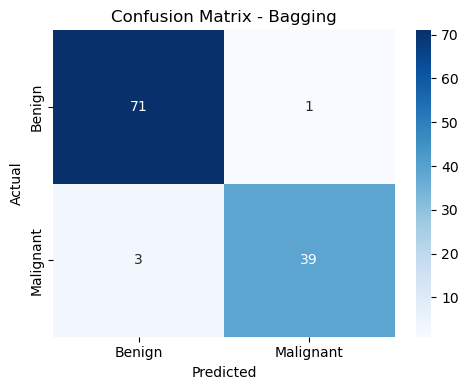

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: assign7_figures\fig05_roc_bagging.png
Saved: assign7_figures\fig05_roc_bagging.eps


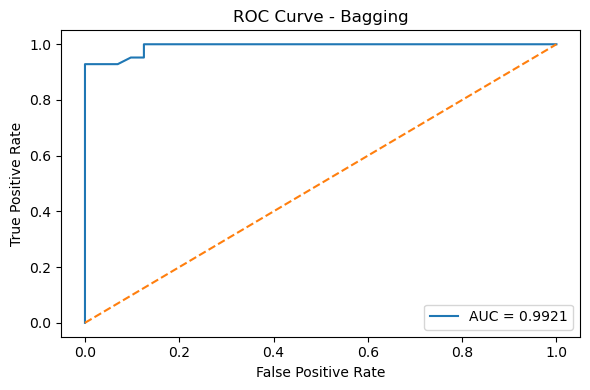

Saved: assign7_figures\fig06_confusion_boosting.png
Saved: assign7_figures\fig06_confusion_boosting.eps


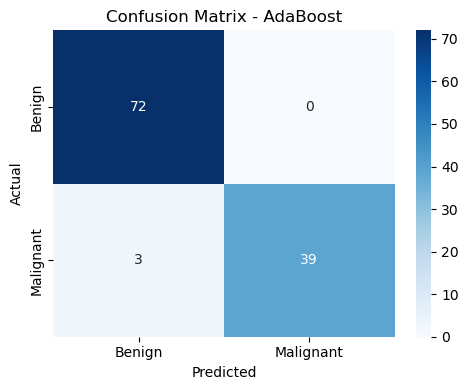

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: assign7_figures\fig07_roc_boosting.png
Saved: assign7_figures\fig07_roc_boosting.eps


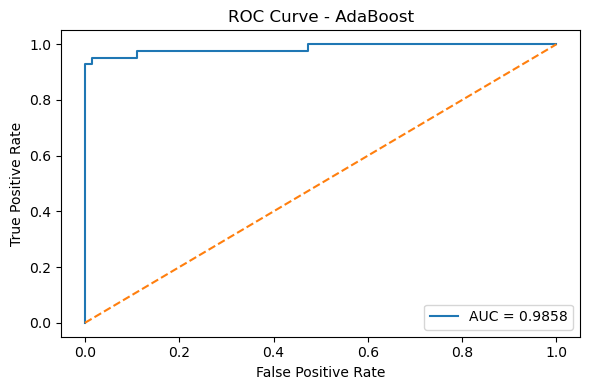

Saved: assign7_figures\fig08_confusion_stacking.png
Saved: assign7_figures\fig08_confusion_stacking.eps


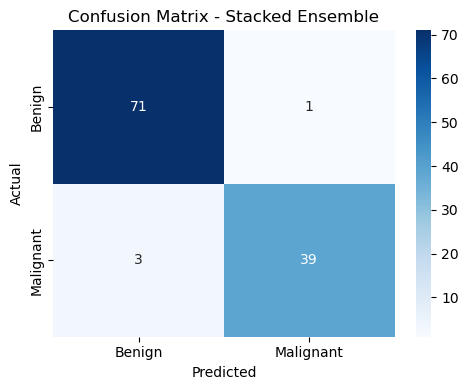

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: assign7_figures\fig09_roc_stacking.png
Saved: assign7_figures\fig09_roc_stacking.eps


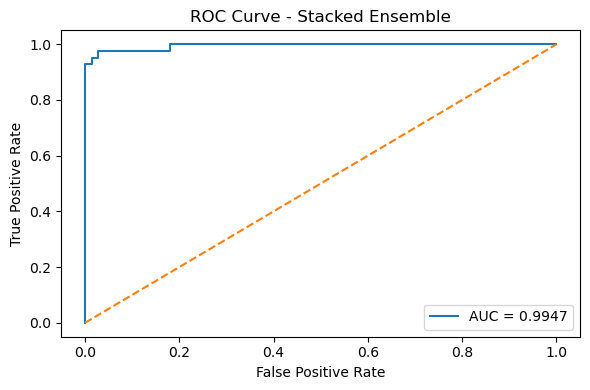

In [14]:
plot_confusion("Bagging", y_test, bag_pred, "fig04_confusion_bagging")
plot_roc("Bagging", y_test, bag_score, "fig05_roc_bagging")

plot_confusion(best_boosting_name, y_test, boost_pred, "fig06_confusion_boosting")
plot_roc(best_boosting_name, y_test, boost_score, "fig07_roc_boosting")

plot_confusion("Stacked Ensemble", y_test, stack_pred, "fig08_confusion_stacking")
plot_roc("Stacked Ensemble", y_test, stack_score, "fig09_roc_stacking")

## Tables matching the experiment sheet

In [15]:
table1_bagging = bagging_cv_results.rename(columns={
    "n_estimators": "n_estimators",
    "max_samples": "max_samples",
    "Avg CV Accuracy (%)": "Avg CV Accuracy (%)",
    "Avg CV F1 Score": "Avg CV F1 Score"
})[["n_estimators", "max_samples", "Avg CV Accuracy (%)", "Avg CV F1 Score"]]

table2_boosting = boosting_cv_results.rename(columns={
    "n_estimators": "n_estimators",
    "learning_rate": "learning_rate",
    "Avg CV Accuracy (%)": "Avg CV Accuracy (%)",
    "Avg CV F1 Score": "Avg CV F1 Score"
})[["Algorithm", "n_estimators", "learning_rate", "Avg CV Accuracy (%)", "Avg CV F1 Score"]]

table3_stacking = stack_cv_results[["Base Models", "Meta Learner", "Avg CV Accuracy (%)", "Avg CV F1 Score"]]

table4_performance = performance_comparison[["Model", "Accuracy (%)", "Precision", "Recall", "F1 Score", "AUC"]]

print("Table 1: Bagging Hyperparameter Evaluation")
display(table1_bagging)

print("Table 2: Boosting Hyperparameter Evaluation")
display(table2_boosting)

print("Table 3: Stacked Ensemble Evaluation")
display(table3_stacking)

print("Table 4: Performance Comparison of Ensemble Models")
display(table4_performance)

Table 1: Bagging Hyperparameter Evaluation


,n_estimators,max_samples,Avg CV Accuracy (%),Avg CV F1 Score
5,50,0.7,96.48,0.9515
0,10,0.7,96.04,0.9469
3,50,1.0,96.04,0.9463
6,10,1.0,96.04,0.9459
7,50,1.0,96.04,0.9467
1,50,0.7,95.60,0.9400
4,10,0.7,94.73,0.9261
2,10,1.0,94.07,0.9171


Table 2: Boosting Hyperparameter Evaluation


,Algorithm,n_estimators,learning_rate,Avg CV Accuracy (%),Avg CV F1 Score
0,AdaBoost,100,0.50,97.14,0.9607
1,AdaBoost,50,1.00,96.70,0.9546
2,AdaBoost,50,0.50,96.48,0.9512
3,AdaBoost,100,1.00,96.48,0.9523
4,Gradient Boosting,100,0.10,96.70,0.9553
5,Gradient Boosting,100,0.10,96.48,0.9514
6,Gradient Boosting,100,0.05,95.60,0.9413
7,Gradient Boosting,50,0.10,95.60,0.9409
8,Gradient Boosting,50,0.10,95.38,0.9371
9,Gradient Boosting,100,0.05,95.16,0.9337


Table 3: Stacked Ensemble Evaluation


,Base Models,Meta Learner,Avg CV Accuracy (%),Avg CV F1 Score
4,SVM + Naive Bayes + Decision Tree,Logistic Regression,96.92,0.9581
5,SVM + Naive Bayes + Decision Tree,Logistic Regression,96.92,0.9580
2,SVM + Naive Bayes + Decision Tree,Logistic Regression,96.26,0.9490
3,SVM + Naive Bayes + Decision Tree,Logistic Regression,96.04,0.9462
1,SVM + Naive Bayes + Decision Tree,Logistic Regression,95.38,0.9372
0,SVM + Naive Bayes + Decision Tree,Logistic Regression,95.16,0.9331


Table 4: Performance Comparison of Ensemble Models


,Model,Accuracy (%),Precision,Recall,F1 Score,AUC
0,AdaBoost,97.37,1.000,0.9286,0.9630,0.9858
1,Bagging,96.49,0.975,0.9286,0.9512,0.9921
2,Stacked Ensemble,96.49,0.975,0.9286,0.9512,0.9947
